In [ ]:
# %%
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from ipywidgets import interact, Dropdown
from sklearn.model_selection import KFold
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, ndcg_score

def cross_val_splits(df, start_year = 2000, years_per_split = 5):
    """Create 5-year splits where each split trains on all years except a 5-year validation window"""
    seasons = sorted(df[df['season'] >= start_year]['season'].unique())
    splits = []
    
    # Create 5-year validation splits, train on all other years
    for i in range(0, len(seasons) - years_per_split + 1, years_per_split):
        val_years = seasons[i:i + years_per_split]
        # All other years are training years
        train_years = [year for year in seasons if year not in val_years]
        
        train_idx = df[df['season'].isin(train_years)].index
        val_idx = df[df['season'].isin(val_years)].index
        
        splits.append((train_idx, val_idx, train_years, val_years))
    
    return splits


def run_cross_val(model, data, features, num_of_selections = 12, target='next_yr_all_star', start_year=2000):
    results = []
    splits = cross_val_splits(data, start_year)

    for fold, (train_idx, val_idx, train_years, val_years) in enumerate(splits, start=1):

        train_df = data.loc[train_idx]
        val_df = data.loc[val_idx]

        # Fit model
        model.fit(train_df[features], train_df[target])

        # Get probabilities for ranking
        val_probs = model.predict_proba(val_df[features])[:, 1]

        val_df_copy = val_df.copy()
        val_df_copy['model_prob'] = val_probs
        val_df_copy['predicted_all_star'] = 0

        # --- Make top-12 predictions per season ---
        for season in val_df_copy['season'].unique():
            season_mask = val_df_copy['season'] == season
            season_data = val_df_copy[season_mask].copy()

            # Sort descending by model probability
            season_data_sorted = season_data.sort_values('model_prob', ascending=False)

            # Top 12 players
            top_n_indices = season_data_sorted.head(num_of_selections).index

            # Mark them as predicted all-stars
            val_df_copy.loc[top_n_indices, 'predicted_all_star'] = 1

        # Write predictions back into main data
        data.loc[val_df_copy.index, 'model_prob'] = val_df_copy['model_prob']
        data.loc[val_df_copy.index, 'predicted_all_star'] = val_df_copy['predicted_all_star']

        # --- Compute per-season metrics ---
        season_metrics = []
        for season, group in val_df_copy.groupby('season'):
            y_true = group[target].values
            y_pred = group['predicted_all_star'].values
            y_prob = group['model_prob'].values

            season_metrics.append({
                'season': season,
                'precision@12': precision_score(y_true, y_pred, zero_division=0),
                'recall@12': recall_score(y_true, y_pred, zero_division=0),
                'f1@12': f1_score(y_true, y_pred, zero_division=0),
                'ndcg@12': ndcg_score([y_true], [y_prob], k=24)
            })

        # --- Aggregate across validation seasons ---
        season_df = pd.DataFrame(season_metrics)
        metrics = {
            'fold': fold,
            'train_seasons': sorted(train_years),
            'val_seasons': sorted(val_years),
            'precision@12': season_df['precision@12'].mean(),
            'recall@12': season_df['recall@12'].mean(),
            'f1@12': season_df['f1@12'].mean(),
            'ndcg@12': season_df['ndcg@12'].mean()
        }

        results.append(metrics)

    return pd.DataFrame(results)


def select_primary_team(team_series,players):
    """
    Selects the player's main team for a season.
    Rules:
    1. Ignore '2TM' rows (combined stat rows).
    2. If one team has more than double the games of any other, use that team.
    3. Otherwise, pick the first non-'2TM' entry.
    """
    # Extract relevant rows from the same player-season group
    group = players.loc[team_series.index]
    team_games = group.groupby('team')['g'].sum().drop(index='2TM', errors='ignore')

    if len(team_games) == 0:
        return team_series.iloc[0]  # fallback if only 2TM

    # If one team has more than double the games of the next most played team
    top_team = team_games.idxmax()
    if len(team_games) > 1:
        second_most = team_games.sort_values(ascending=False).iloc[1]
        if team_games[top_team] > 2 * second_most:
            return top_team

    # Otherwise, fall back to the first non-'2TM' team
    non_2tm = [t for t in team_series if t != '2TM']
    return non_2tm[0] if non_2tm else team_series.iloc[0]

def fill_missing_seasons(players_df):
    """Ensure each player has continuous seasons from first to last, filling missing ones with blank entries."""
    all_rows = []
    for pid, group in players_df.groupby('player_id', group_keys=False):
        min_season, max_season = group['season'].min(), group['season'].max()
        all_seasons = set(range(min_season, max_season + 1))
        existing = set(group['season'])
        missing = all_seasons - existing

        # Add existing rows first
        all_rows.append(group)

        for season in missing:
            # Find the last known team before this missing season
            prior_seasons = group[group['season'] < season]
            if not prior_seasons.empty:
                last_team = prior_seasons.iloc[-1]['team']
            else:
                last_team = np.nan
        # Create blank rows for missing seasons
        for season in missing:
            blank_row = {
                'player_id': pid,
                'player': group['player'].iloc[-1],
                'season': season,
                'team': last_team,
                'all_star': 0,   # assume not All-Star if no data
            }
            all_rows.append(pd.DataFrame([blank_row]))

    # Combine everything back
    filled_df = pd.concat(all_rows, ignore_index=True)

    # Sort for good measure
    filled_df = filled_df.sort_values(['player_id', 'season']).reset_index(drop=True)
    return filled_df
def get_proximity_to_prime(age):
    if 27 <= age <= 31:
        return 100
    elif age < 27:
        distance_from_prime = 27 - age
        return max(0, 100 - (distance_from_prime * 4)) # scale scores upwards as players approach their primes
    else:  # age > 31
        distance_from_prime = 31 - age
        return -(max(0, 100 - (distance_from_prime * 10))) # scale score lower as players age past 31
def get_conference(team, season):
    """Returns 'East' or 'West' based on team abbreviation and season."""
    
    # Teams that never changed
    eastern_conference = ['BOS', 'BRK', 'NYK', 'PHI', 'TOR', 'CHI', 'CLE', 'DET', 'IND', 'MIL', 'ATL', 'CHA', 'WAS','NJN','ORL','MIA','CHH','NOH','CHO']
    western_conference = ['GSW', 'LAC', 'LAL', 'SAC', 'POR', 'DEN', 'UTA', 'MIN', 'NOP', 'OKC', 'DAL', 'HOU', 'SAS','VAN','SEA','NOK','PHO','MEM']
        
        # Historical teams
 
            
            # New Orleans (complex history)
    if season > 2004:
        if team == 'NOH':
            return 'West'
    if team in eastern_conference:
        return 'East'
    if team in western_conference:
        return 'West'
            
    return None  # Unknown team

def display_all_star_team(east_df, west_df, model_results,num_of_selections=12, cols=['player', 'team']):
    
    # Define available seasons dynamically (based on data)
    min_season = int(min(east_df['season'].min(), west_df['season'].min()))
    max_season = int(max(east_df['season'].max(), west_df['season'].max()))
    
    def plot_for_season(season):
        # --- Select top 12 predicted from each conference ---
        east_top = east_df[(east_df['season'] == season) & 
                           (east_df['predicted_all_star'] == 1)].head(num_of_selections)
        west_top = west_df[(west_df['season'] == season) & 
                           (west_df['predicted_all_star'] == 1)].head(num_of_selections)
        all_preds = pd.concat([east_top, west_top], ignore_index=True)

        # Identify true next-year All-Stars (for missed cases)
        true_east = east_df[(east_df['season'] == season) & 
                            (east_df['next_yr_all_star'] == 1)]
        true_west = west_df[(west_df['season'] == season) & 
                            (west_df['next_yr_all_star'] == 1)]
        all_true = pd.concat([true_east, true_west], ignore_index=True)

        # --- Determine categories ---
        correct = all_preds[all_preds['next_yr_all_star'] == 1]
        incorrect = all_preds[all_preds['next_yr_all_star'] == 0]
        missed = all_true[~all_true['player'].isin(all_preds['player'])]

        # --- Prepare display rows ---
        rows, row_colors, text_colors = [], [], []

        # Header
        rows.append([f"Predictions for {season + 1} season", ""])
        row_colors.append(["#FFFFFF", "#FFFFFF"])
        text_colors.append(["black", "black"])

        def add_rows(df, color, text_color="black"):
            for _, r in df.iterrows():
                player = str(r.get(cols[0], '') or '')
                team = str(r.get(cols[1], '') or '')
                rows.append([player, team])
                row_colors.append([color, color])
                text_colors.append([text_color, text_color])

        # Add each group
        add_rows(correct, "#C6F6C6")   # green
        add_rows(incorrect, "#FFB3B3") # red

        # --- Build Figure with Two Axes ---
        fig, (ax_table, ax_metrics) = plt.subplots(1, 2, figsize=(12, 8))
        ax_table.axis("off")
        ax_metrics.axis("off")

        # --- Left: Prediction Table ---
        table = ax_table.table(
            cellText=rows,
            cellLoc='left',
            colLabels=cols,
            loc='center',
            cellColours=row_colors
        )

        for i, color_row in enumerate(row_colors):
            for j in range(len(color_row)):
                table[(i, j)].get_text().set_color(text_colors[i][j])

        table.auto_set_font_size(False)
        table.set_fontsize(11)
        table.scale(1.8, 1.5)

        # Legend
        legend_items = [
            mpatches.Patch(color='#C6F6C6', label=' Correct Prediction'),
            mpatches.Patch(color='#FFB3B3', label=' Incorrect Prediction')
        ]

        ax_table.legend(handles=legend_items, loc='lower right',  bbox_to_anchor=(1.35, -0.05), fontsize=9)

        # --- Right: Model Performance Metrics as a Table ---
        metrics_data = []
        for metric in ['ndcg@12', 'f1@12']:
            mean_val = model_results.loc['mean', metric]
            std_val = model_results.loc['std', metric]
            metrics_data.append([metric, f"{mean_val:.3f} ± {std_val:.3f}"])

        metrics_table = ax_metrics.table(
            cellText=metrics_data,
            colLabels=['Metric', 'Value'],
            loc='center',
            cellLoc='center'
        )
        metrics_table.auto_set_font_size(False)
        metrics_table.set_fontsize(12)
        metrics_table.scale(1, 2)  # make it taller

        ax_metrics.set_title("Model Summary", fontsize=14, fontweight='bold')
        ax_metrics.axis("off")

        plt.tight_layout()
        plt.show()
    interact(plot_for_season,season=Dropdown(options=list(range(min_season, max_season + 1)),value=max_season,description="Season"))
def display_top_guesses(east_df, west_df, num_of_selections=12, cols=['player', 'team']):
    """Display top predicted All-Stars from each conference across all seasons."""
      # Define available seasons dynamically (based on data)
    min_season = int(min(east_df['season'].min(), west_df['season'].min()))
    max_season = int(max(east_df['season'].max(), west_df['season'].max()))
    def plot_for_season(season):
        # --- Select top 12 predicted from each conference ---
        east_top = east_df[(east_df['season'] == season) & 
                           (east_df['predicted_all_star'] == 1)].head(num_of_selections)
        west_top = west_df[(west_df['season'] == season) & 
                           (west_df['predicted_all_star'] == 1)].head(num_of_selections)
        all_preds = pd.concat([east_top, west_top], ignore_index=True)

        # Identify true next-year All-Stars (for missed cases)
        true_east = east_df[(east_df['season'] == season) & 
                            (east_df['next_yr_all_star'] == 1)]
        true_west = west_df[(west_df['season'] == season) & 
                            (west_df['next_yr_all_star'] == 1)]
        all_true = pd.concat([true_east, true_west], ignore_index=True)

        # --- Determine categories ---
        correct = all_preds[all_preds['next_yr_all_star'] == 1]
        incorrect = all_preds[all_preds['next_yr_all_star'] == 0]
        missed = all_true[~all_true['player'].isin(all_preds['player'])]
        # --- Prepare display rows ---
        rows, row_colors, text_colors = [], [], []

        # Header
        rows.append([f"Predictions for {season + 1} season", ""])
        row_colors.append(["#FFFFFF", "#FFFFFF"])
        text_colors.append(["black", "black"])

        def add_rows(df, color, text_color="black"):
            for _, r in df.iterrows():
                player = str(r.get(cols[0], '') or '')
                team = str(r.get(cols[1], '') or '')
                rows.append([player, team])
                row_colors.append([color, color])
                text_colors.append([text_color, text_color])

        # Add each group
        add_rows(correct, "#C6F6C6")   # green
        add_rows(incorrect, "#FFB3B3") # red

        # --- Build Figure with Two Axes ---
        fig, (ax_table, ax_metrics) = plt.subplots(1, 2, figsize=(12, 8))
        ax_table.axis("off")
        ax_metrics.axis("off")

        # --- Left: Prediction Table ---
        table = ax_table.table(
            cellText=rows,
            cellLoc='left',
            colLabels=cols,
            loc='center',
            cellColours=row_colors
        )

        for i, color_row in enumerate(row_colors):
            for j in range(len(color_row)):
                table[(i, j)].get_text().set_color(text_colors[i][j])

        table.auto_set_font_size(False)
        table.set_fontsize(11)
        table.scale(1.8, 1.5)

        # Legend
        legend_items = [
            mpatches.Patch(color='#C6F6C6', label=' Correct Prediction'),
            mpatches.Patch(color='#FFB3B3', label=' Incorrect Prediction')
        ]

        ax_table.legend(handles=legend_items, loc='lower right',  bbox_to_anchor=(1.35, -0.05), fontsize=9)
        metrics_table = ax_metrics.table(
            cellText=[['All stars captured', f"{(len(correct)/24 * 100):.2f}%"]],
            loc='center',
            cellLoc='center'
        )
        metrics_table.auto_set_font_size(False)
        metrics_table.set_fontsize(12)
        metrics_table.scale(1, 2)  # make it taller
       
        ax_metrics.set_title(f"Models top {num_of_selections * 2 } predictions", fontsize=14, fontweight='bold')
        ax_metrics.axis("off")

        plt.tight_layout()
        plt.show()
    interact(plot_for_season,season=Dropdown(options=list(range(min_season, max_season + 1)),value=max_season,description="Season"))



In [143]:
eastern_conference = ['BOS', 'BKN', 'NYK', 'PHI', 'TOR', 'CHI', 'CLE', 'DET', 'IND', 'MIL', 'ATL', 'CHA', 'WAS','NJN','ORL','MIA','CHH','NOH']
western_conference = ['GSW', 'LAC', 'LAL', 'SAC', 'POR', 'DEN', 'UTA', 'MIN', 'NOP', 'OKC', 'DAL', 'HOU', 'SAS','VAN','SEA','NOK','PHX','MEM']
advanced_stats = pd.read_csv('data/advanced.csv')
team_stats = pd.read_csv('data/Team_Summaries.csv')
players = pd.read_csv("data/Players_per_game.csv")
players = players[players['season'] >= 2000]
players = players[players['season'] <= 2025]
players = fill_missing_seasons(players)

In [144]:
team_stats['team_win_pct'] = team_stats['w'] / (team_stats['w'] + team_stats['l'])

# --- Select only relevant columns ---
win_pct = team_stats[['abbreviation', 'season', 'team_win_pct']].copy()

# --- Merge win rate into player dataframe using team abbreviation ---
players = players.merge(
    win_pct,
    left_on=['team', 'season'],
    right_on=['abbreviation', 'season'],
    how='left'
)


players["points_per_36"] = players['mp_per_game'] / 36 * players['pts_per_game']
players['stocks_per_game'] = players['blk_per_game'] + players['stl_per_game']
players = players.sort_values(['player_id', 'season']).reset_index(drop=True)

players['ast_per_36'] = players['ast_per_game'] / players['mp_per_game'] * 36
adv_cols = ['player_id','season','usg_percent','ts_percent','bpm','dws','vorp','per','ws_48','tov_percent']
players = players.merge(advanced_stats[adv_cols], on=['player_id','season'], how='left')
players['tov_ratio'] =  players['tov_per_game'] / players['ast_per_game'] 
players['proximity_to_prime'] = players['age'].apply(get_proximity_to_prime)
players = players.sort_values(['player_id', 'season']).reset_index(drop=True)

players['offensive_efficiency'] = players['usg_percent'] * players['ts_percent'] * players['per']
players['box_score_volume'] = players['pts_per_game'] + players['ast_per_game'] + players['trb_per_game']
players['shot_volume'] = players['x2pa_per_game'] +  players['x3pa_per_game'] + players['fta_per_game']
players = players.groupby(['player_id', 'season']).agg({
        'player': lambda x: x.iloc[-1],
        'age': 'mean',                     # average age across season if duplicates
        'team': lambda x: select_primary_team(x,players),
        'pos': lambda x: x.mode().iat[0] if not x.mode().empty else x.iloc[-1],  # most common position
        'mp_per_game': 'mean',             # average minutes per game
        'fg_per_game': 'mean',
        'fga_per_game': 'mean',
        'fg_percent': 'mean',
        'x3p_per_game': 'mean',
        'x3pa_per_game': 'mean',
        'x3p_percent': 'mean',
        'x2p_per_game': 'mean',
        'x2pa_per_game': 'mean',
        'x2p_percent': 'mean',
        'e_fg_percent': 'mean',
        'ft_per_game': 'mean',
        'fta_per_game': 'mean',
        'ft_percent': 'mean',
        'orb_per_game': 'mean',
        'drb_per_game': 'mean',
        'trb_per_game': 'mean',
        'ast_per_game': 'mean',
        'stl_per_game': 'mean',
        'blk_per_game': 'mean',
        'tov_per_game': 'mean',
        'pf_per_game': 'mean',
        'pts_per_game': 'mean',
        'usg_percent': 'mean',
        'all_star': 'max',  # if player was all-star with either team
        'vorp': 'mean',
        'tov_ratio': 'mean',
        'tov_percent': 'mean',
        'points_per_36': 'mean',
        'proximity_to_prime': 'mean', 
        'offensive_efficiency': 'mean',
        'box_score_volume': 'mean',
        'shot_volume': 'mean',
        'team_win_pct': 'mean',
        'per': 'mean',
        'shot_volume': 'mean',
        'ws_48': 'mean',
        'dws': 'mean',
        'ts_percent': 'mean',
        'bpm': 'mean',
}).reset_index()
# One-hot encode Guard / Forward / Center

players['win_contributions'] = players['team_win_pct'] * players['ws_48'] 
  # only up to 2023 since we want to predict 2024
players_for_display = players
players['next_yr_all_star'] = players.groupby('player_id')['all_star'].shift(-1)
players['next_yr_all_star'] = players['next_yr_all_star'].fillna(0)

# Apply to players
players['conference'] = players.apply(lambda row: get_conference(row['team'], row['season']), axis=1)


# Split by conference

players['next_yr_conference'] = players.groupby('player_id')['conference'].shift(-1)


In [145]:
players['defensive_contributions'] =  (players['stl_per_game'] + players['blk_per_game'] + players['drb_per_game']) 
players['win_weighted_defense'] = players['defensive_contributions'] * players['dws']
players['high_impact_winners'] = players['ws_48'] * players['vorp']
players['impact_scorers'] = players['bpm'] * players['points_per_36']
players["delta_vorp"] = players.groupby("player")["vorp"].diff()
players["delta_vorp"] = players["delta_vorp"].fillna(0)
players['offensive_efficiency'] = players['per'] * (players['ft_per_game'])

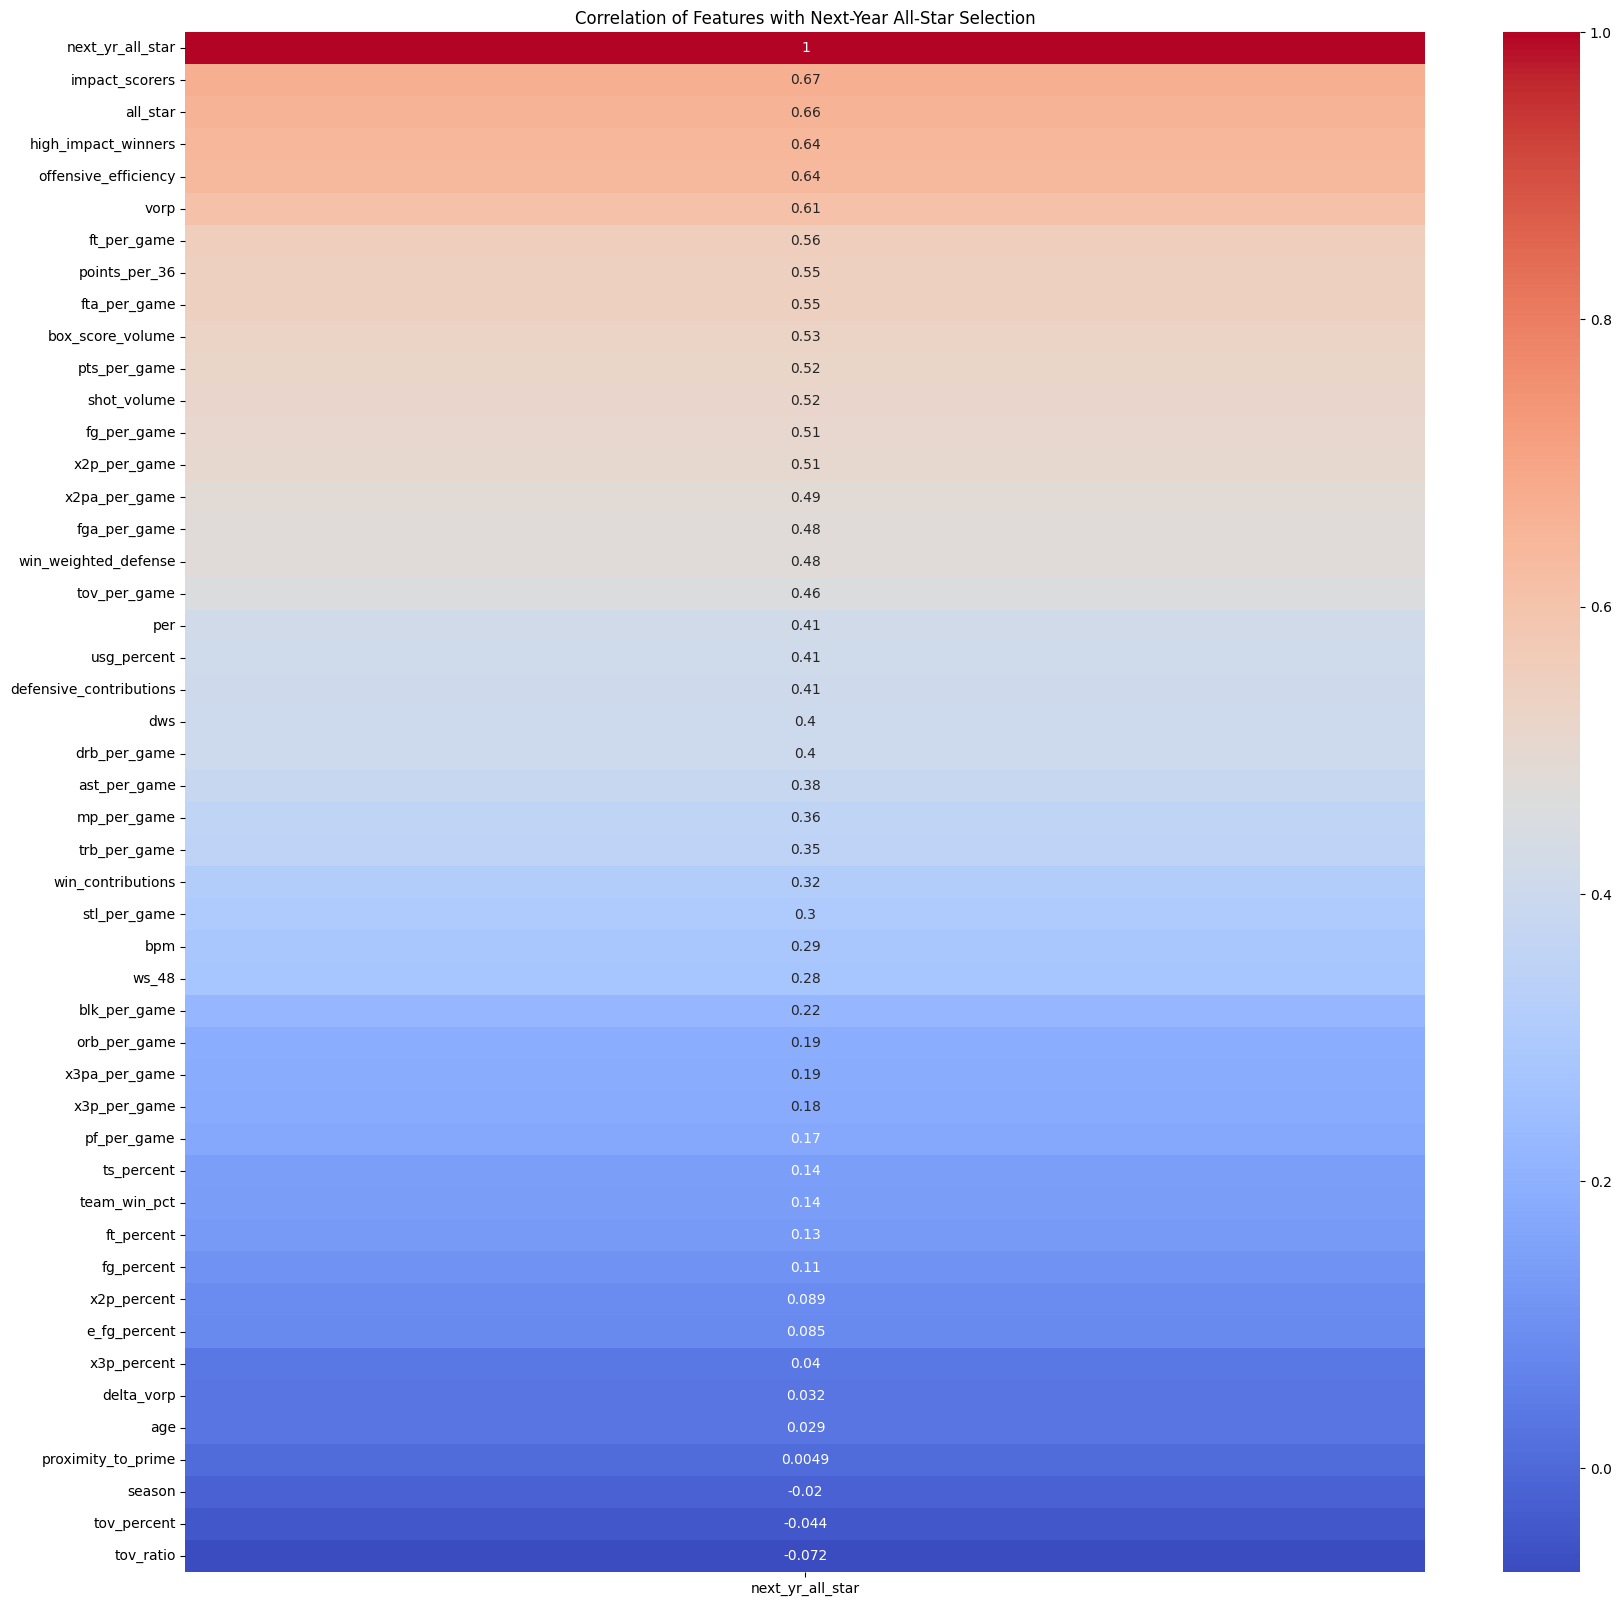

In [146]:
east_players = players[players['next_yr_conference'] == 'East']
west_players = players[players['next_yr_conference'] == 'West']
corr = west_players.corr(numeric_only=True)
plt.figure(figsize=(20,20))
sns.heatmap(corr[['next_yr_all_star']].sort_values('next_yr_all_star', ascending=False), annot=True, cmap='coolwarm')
plt.title("Correlation of Features with Next-Year All-Star Selection")
plt.show()

In [147]:

import xgboost as xgb
from sklearn.metrics import classification_report

east_model = xgb.XGBClassifier(
      n_estimators=600,
    max_depth=6,
    learning_rate=0.015,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,  # smoother
    gamma=2,             # less aggressive splits
    random_state=0,
    objective = 'rank:ndcg',
    eval_metric='ndcg@12',

      # tilt slightly toward recall
)
west_model = xgb.XGBClassifier(
         n_estimators=600,
    max_depth=6,
    learning_rate=0.015,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,  # smoother
    gamma=2,             # less aggressive splits
    random_state=0,
    objective = 'rank:ndcg',
    eval_metric='ndcg@12',
    

)

In [148]:


target = 'next_yr_all_star'


#conference_features = ['vorp','offensive_efficiency','fta_per_game','box_score_volume','all_star','proximity_to_prime','win_contributions','volume_efficient', 'win_weighted_defense']
conference_features = ['high_impact_winners','all_star','impact_scorers','proximity_to_prime','offensive_efficiency']
#conference_features = ['vorp','delta_vorp', 'offensive_efficiency', 'proximity_to_prime','age','usg_percent','per','pos_guard','pos_forward', 'pos_center','ws_48','delta_usg', 'team_win_pct','all_star','all_star_selections']
east_metrics = run_cross_val(east_model, east_players, conference_features, 15, target)
west_metrics = run_cross_val(west_model, west_players, conference_features, 15, target)
combined_results = pd.concat([
    east_metrics.assign(conference='East'),
    west_metrics.assign(conference='West')
])

C:\Users\b22ke\AppData\Local\Temp\ipykernel_19676\2827143926.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[val_df_copy.index, 'model_prob'] = val_df_copy['model_prob']
C:\Users\b22ke\AppData\Local\Temp\ipykernel_19676\2827143926.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[val_df_copy.index, 'predicted_all_star'] = val_df_copy['predicted_all_star']
C:\Users\b22ke\AppData\Local\Temp\ipykernel_19676\2827143926.py:64: SettingWithCopyWarning: 
A value is trying to be set on a co

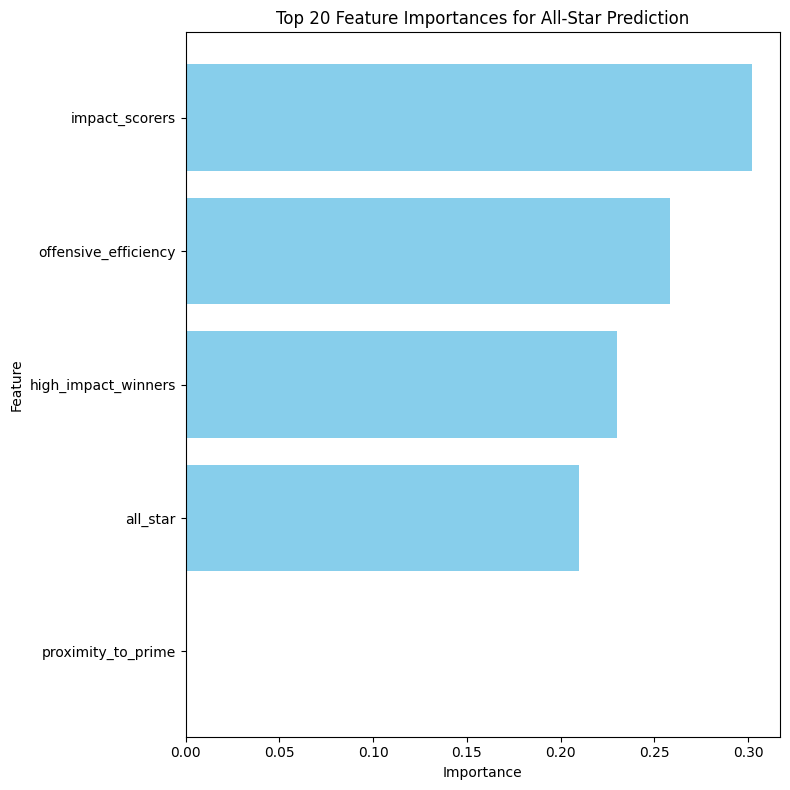

In [149]:
importances = east_model.feature_importances_
features = east_model.feature_names_in_

feat_imp = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp = feat_imp.sort_values('Importance', ascending=True).tail(20)

plt.figure(figsize=(8, 8))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='skyblue')
plt.title("Top 20 Feature Importances for All-Star Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

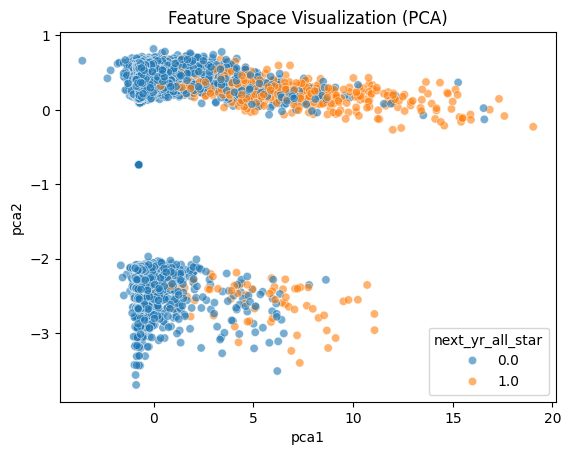

In [150]:

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

feature_cols = conference_features
X_scaled = StandardScaler().fit_transform(players[feature_cols].fillna(0))

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)

players['pca1'], players['pca2'] = pca_coords[:,0], pca_coords[:,1]

sns.scatterplot(data=players, x='pca1', y='pca2', hue='next_yr_all_star', alpha=0.6)
plt.title('Feature Space Visualization (PCA)')
plt.show()

In [ ]:

# Compute summary statistics for each conference
summary_by_conference = combined_results.groupby('conference')[['ndcg@12', 'precision@12', 'recall@12', 'f1@12']].agg(['mean'])

# Compute overall (East + West combined)
overall_summary = combined_results[['ndcg@12', 'precision@12', 'recall@12', 'f1@12']].mean().to_frame('mean').T
overall_std = combined_results[['ndcg@12', 'precision@12', 'recall@12', 'f1@12']].std().to_frame('std').T
overall_summary = pd.concat([overall_summary, overall_std])
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches





display_all_star_team(east_players, west_players,overall_summary)
display_top_guesses(east_players, west_players, 15)

interactive(children=(Dropdown(description='Season', index=24, options=(2000, 2001, 2002, 2003, 2004, 2005, 20…

interactive(children=(Dropdown(description='Season', index=24, options=(2000, 2001, 2002, 2003, 2004, 2005, 20…